## Install and import required libraries

In [1]:
# !pip install scikit-learn
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install seaborn
# !pip install xgboost
# !pip install pyarrow
# ! pip install mlxtend
# !conda install lightgbm -y


In [161]:
import pandas as pd
import numpy as np
import glob
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from mlxtend.plotting import plot_decision_regions
import lightgbm as lgbm
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [8]:
#load single file to look at contents
df = pd.read_csv('data/ids_0.csv')

#get names of columns
print(df.columns)

#display data types
print(df.dtypes)

#disply dataframe head
df.head()

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,53,61205,4,2,136,428,34,34,34.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,53,222,2,2,90,172,45,45,45.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,53,23759,2,2,70,126,35,35,35.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,80,401,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,57406,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [9]:
#combine all csv, json, and parquet files into single dataframe

def extract() -> pd.DataFrame:
    #main dataframe that everything will be concatenated to
    data = pd.DataFrame()

    #extract CSV files
    for csvfile in glob.glob('data/*.csv'):
        tmp_df = pd.read_csv(csvfile)
        data = pd.concat([data, tmp_df], ignore_index=True)
    
    #extract JSON files
    for jsonfile in glob.glob('data/*.json'):
        tmp_df = pd.read_json(jsonfile, lines=True)
        data = pd.concat([data, tmp_df], ignore_index=True)

    #extract Parquet files
    for parquetfile in glob.glob('data/*.parquet'):
        tmp_df = pd.read_parquet(parquetfile)
        data = pd.concat([data, tmp_df], ignore_index=True)
    
    #return combined dataframe
    return data

In [10]:
#call extract function to combine all files into single dataframe
df = extract()

print("Shape of combined dataframe:", df.shape)

df.head()

Shape of combined dataframe: (63129, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,55109,17,1,1,6,6,6,6,6.0,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,53,113594958,4,4,152,362,45,31,38.0,8.082904,...,32,240.0,0.0,240,240,114000000.0,0.0,114000000,114000000,BENIGN
2,53,30485,1,1,81,209,81,81,81.0,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,53,30445,1,1,53,81,53,53,53.0,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,53,70860,1,1,56,72,56,56,56.0,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [11]:
#verify the extracted data
#remove leading/trailing whitespace from column names
df.columns = df.columns.str.strip()  

#check label distribution
print(df['Label'].value_counts())

Label
DoS Hulk            31027
DoS GoldenEye       20586
BENIGN               6006
DoS Slowhttptest     5499
Heartbleed             11
Name: count, dtype: int64


In [12]:
#Tranform 

def transform(df: pd.DataFrame) -> pd.DataFrame:

    #remove Heartbleed rows since its not a DOS attack
    df = df[df['Label'] != 'Heartbleed']

    #remove any duplicate rows
    df = df.drop_duplicates()

    #remap labels (benign stays but all dos attacks get remapped to "attack")
    df['Label'] = df['Label'].apply(lambda x: 'BENIGN' if x == 'BENIGN' else 'attack')

    #replace infinite values with NaN and then drop rows with NaN values
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna()

    return df


In [13]:
#call transform function to clean the data
df = transform(df)
print("Shape of transformed dataframe:", df.shape)

#check label distribution after transformation
print(df['Label'].value_counts())

Shape of transformed dataframe: (49348, 79)
Label
attack    44402
BENIGN     4946
Name: count, dtype: int64


In [14]:
#load the data into a csv file
df.to_csv('data/cleaned_data.csv', index=False)

In [15]:
#read in cleaned csv file as a dataframe
df = pd.read_csv('data/cleaned_data.csv')
print(df.shape)

(49348, 79)


In [102]:
#exploratory data analysis - are there NA values? 
print(df.isnull().sum().sum())
#0 = no NA values

0


In [103]:
#find correlation values between features
df.iloc[:, :-1].corr().head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
Destination Port,1.000000,-0.156043,-0.005442,-0.003794,0.028082,-0.003673,0.038043,0.001517,0.082406,0.041678,...,-0.001763,-0.068684,-0.043431,-0.011544,-0.043468,-0.041802,-0.133849,-0.029399,-0.138469,-0.128710
Flow Duration,-0.156043,1.000000,0.020260,0.018494,0.053046,0.016987,0.162263,-0.119957,0.020200,0.176788,...,0.015343,-0.240128,0.074984,0.086650,0.089914,0.058041,0.937066,0.176049,0.962137,0.906042
Total Fwd Packets,-0.005442,0.020260,1.000000,0.999260,0.507563,0.998963,0.021027,-0.004720,-0.000998,0.003234,...,0.998771,-0.011752,0.005303,0.010078,0.007895,0.003435,-0.004229,0.001417,-0.003976,-0.004360
Total Backward Packets,-0.003794,0.018494,0.999260,1.000000,0.507672,0.998762,0.020934,-0.003151,-0.000783,0.003958,...,0.998633,-0.019082,-0.005592,0.003061,-0.003751,-0.006084,-0.002442,-0.004409,-0.003171,-0.001898
Total Length of Fwd Packets,0.028082,0.053046,0.507563,0.507672,1.000000,0.495664,0.372647,0.020843,0.349116,0.337064,...,0.506178,-0.024757,0.026835,0.228250,0.082583,-0.021293,-0.004301,0.006189,-0.001118,-0.004837


In [104]:
#data preprocessing

df = df.drop_duplicates()

In [105]:
#count number of attack vs benign labels
print(df['Label'].value_counts())

Label
attack    41264
BENIGN     4945
Name: count, dtype: int64


In [121]:
#splitting df data into train and test 
x_train, x_test = train_test_split(df, train_size=0.75)

In [122]:
print('Training dataframe shape:',x_train.shape)
print('Testing dataframe shape:',x_test.shape)

Training dataframe shape: (34656, 79)
Testing dataframe shape: (11553, 79)


In [123]:
# scale x_train and x_test with x_train trained scaler
scaler = StandardScaler().set_output(transform="pandas")

#removed 'label' to avoid error in scaling
x_train_scaled = scaler.fit_transform(x_train.iloc[:, :-1])
x_test_scaled = scaler.transform(x_test.iloc[:, :-1])

#adding back the "label" feature
x_train_scaled['Label'] = x_train['Label']
x_test_scaled['Label'] = x_test['Label']

print("Shape of of training dataframe after scaling:", x_train_scaled.shape)
print("Shape of of testing dataframe after scaling:", x_test_scaled.shape)



Shape of of training dataframe after scaling: (34656, 79)
Shape of of testing dataframe after scaling: (11553, 79)


In [124]:
pd.DataFrame(x_train_scaled).describe()
#std = 1 and mean is around 0, standardized

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,3.465600e+04,3.465600e+04,3.465600e+04,3.465600e+04,3.465600e+04,3.465600e+04,3.465600e+04,3.465600e+04,3.465600e+04,3.465600e+04,...,3.465600e+04,3.465600e+04,3.465600e+04,3.465600e+04,3.465600e+04,3.465600e+04,3.465600e+04,3.465600e+04,3.465600e+04,3.465600e+04
mean,2.255301e-17,-7.134951e-17,1.640219e-18,-2.050273e-18,3.895519e-18,2.460328e-18,4.756634e-17,1.066142e-17,-2.255301e-17,-1.640219e-18,...,-4.100547e-19,8.570143e-17,7.545006e-17,-9.021203e-18,-9.841312e-18,2.542339e-17,-1.992866e-16,-1.517202e-17,5.740765e-17,1.496700e-17
std,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,...,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00
min,-1.571803e-01,-1.190413e+00,-5.762862e-02,-3.978723e-02,-1.970953e-01,-3.111205e-02,-9.910821e-01,-1.076491e-01,-6.357058e-01,-9.873787e-01,...,-2.249119e-02,-4.705232e+00,-3.036254e-01,-8.328537e-02,-3.057135e-01,-2.921230e-01,-1.024706e+00,-2.156491e-01,-1.058208e+00,-9.868566e-01
25%,-1.460312e-01,-9.651023e-01,-2.799295e-02,-2.523309e-02,-1.626306e-01,-3.109226e-02,-8.378740e-01,-1.076491e-01,-2.899087e-01,-9.873787e-01,...,-1.246901e-02,-1.451867e+00,-3.036254e-01,-8.328537e-02,-3.057135e-01,-2.921230e-01,-1.024706e+00,-2.156491e-01,-1.058208e+00,-9.868566e-01
50%,-1.460312e-01,2.770259e-01,-8.235837e-03,-3.401886e-03,-4.200385e-02,7.121071e-03,1.664899e-01,-1.076491e-01,-1.208346e-01,1.244071e-01,...,-1.246901e-02,5.001524e-01,-3.031097e-01,-8.328537e-02,-3.052231e-01,-2.916051e-01,-5.990007e-01,-2.156491e-01,-3.250621e-01,-7.599071e-01
75%,-1.460312e-01,1.095862e+00,1.152128e-02,3.875181e-03,-1.814363e-02,7.121071e-03,2.856517e-01,-1.076491e-01,9.515311e-02,3.742795e-01,...,-2.446838e-03,5.001524e-01,-2.985634e-01,-8.328537e-02,-3.008999e-01,-2.881231e-01,1.201712e+00,-2.156491e-01,1.182341e+00,1.210734e+00
max,8.796824e+00,1.599997e+00,1.841577e+02,1.843247e+02,1.380044e+02,1.849519e+02,3.848553e+01,3.095427e+01,2.264536e+01,4.296946e+01,...,1.843054e+02,4.404191e+00,7.408496e+00,2.898635e+01,1.591404e+01,7.547164e+00,1.707095e+00,9.454803e+00,1.682524e+00,1.709573e+00


In [125]:
#feature selection

#drop all columns with 0 variance
def varcheck(df: pd.DataFrame) -> pd.DataFrame:
    del_list = []
    for column in df.columns.tolist():
        if df[column].dtype == 'int64':
            if df[column].var() >= 0.95:
                del_list.append(column)
                

    return df.drop(columns=del_list)                  

In [126]:
x_train_scaled = varcheck(x_train_scaled)
columns_kept = list(x_train_scaled.columns)
x_test_scaled = x_train_scaled[columns_kept]

#Only using varcheck() on df_train and applying the same transformations to df_test

print("Shape of of training dataframe after variance threshold:", x_train_scaled.shape)
print("Shape of of testing dataframe after variance threshold:", x_test_scaled.shape)

Shape of of training dataframe after variance threshold: (34656, 79)
Shape of of testing dataframe after variance threshold: (34656, 79)


In [127]:
#looking for a pair of features that correlate, then drop one of them (if correlation is equal or greater to 0.95)

def corrcheck(df: pd.DataFrame) -> pd.DataFrame:
    clean_list = []
    keep_list = []
    corr_df = df.iloc[:, :-1].corr()
    for column in corr_df.columns.tolist():
        temp_df = corr_df[column]
        for row in range(len(temp_df)):
            if temp_df[row] >= 0.95 and temp_df.index[row] != column and column not in keep_list and temp_df[row] != 1:
                clean_list.append(column)
                keep_list.append(temp_df.index[row]) 

    print(f'{len(set(clean_list))} Correlated features dropped:',set(clean_list))
    return df.drop(columns=clean_list)        

In [128]:
columns_kept = list()
x_train_scaled = corrcheck(x_train_scaled)
columns_kept = list(x_train_scaled.columns)
x_test_scaled = x_train_scaled[columns_kept]


print("Shape of of training dataframe after correlation correction:", x_train_scaled.shape)
print("Shape of of testing dataframe after correlation correction:", x_test_scaled.shape)

14 Correlated features dropped: {'PSH Flag Count', 'Subflow Fwd Packets', 'Packet Length Mean', 'Flow Duration', 'Avg Bwd Segment Size', 'Flow Packets/s', 'Idle Mean', 'Total Fwd Packets', 'Bwd IAT Std', 'Packet Length Variance', 'Bwd Packet Length Max', 'Active Mean', 'Bwd IAT Total', 'Bwd Packet Length Mean'}
Shape of of training dataframe after correlation correction: (34656, 65)
Shape of of testing dataframe after correlation correction: (34656, 65)


/var/folders/hy/sng9twds677254718xcrwdtc0000gq/T/ipykernel_43947/3412692051.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if temp_df[row] >= 0.95 and temp_df.index[row] != column and column not in keep_list and temp_df[row] != 1:


In [129]:
#load the x_train and x_test dataframes to csv
x_train_scaled.to_csv('data/x_train_data.csv', index=False)
x_test_scaled.to_csv('data/x_test_data.csv', index=False)

In [130]:
#function to turn 'Label' to binary, attack = 1, benign = 0
def label2int(df: pd.DataFrame) -> pd.DataFrame:
    df = df.apply(lambda x: 0 if x == 'BENIGN' else 1)
    return df


In [131]:
# reading in testing and training for prediction models

X_train = pd.read_csv('data/x_train_data.csv')
y_train = X_train['Label']
X_test = pd.read_csv('data/x_test_data.csv')
y_test = X_test['Label']


#remove label feature from training
X_train.drop(columns='Label', inplace=True)
X_test.drop(columns='Label', inplace=True)


#convert labels to binary
y_train = label2int(y_train)
y_test = label2int(y_test)

In [132]:
#perceptron model
perceptron = Perceptron(eta0=0.001, random_state=1)
perceptron = perceptron.fit(X_train, y_train)
pred = perceptron.predict(X_test)

In [133]:
#evaluate model prediction quality

acc_perc = accuracy_score(y_test, pred)
f1score_perc = f1_score(y_test, pred)
precision_perc = precision_score(y_test, pred)
recall_perc = recall_score(y_test, pred)

print('Perceptron Model')
print('-'*20)
print('Accuracy: {:.3f}'.format(acc_perc))
print('Precision: {:.3f}'.format(precision_perc))
print('Recall: {:.3f}'.format(recall_perc))
print('F1-score: {:.3f}'.format(f1score_perc))

Perceptron Model
--------------------
Accuracy: 0.987
Precision: 0.989
Recall: 0.996
F1-score: 0.993


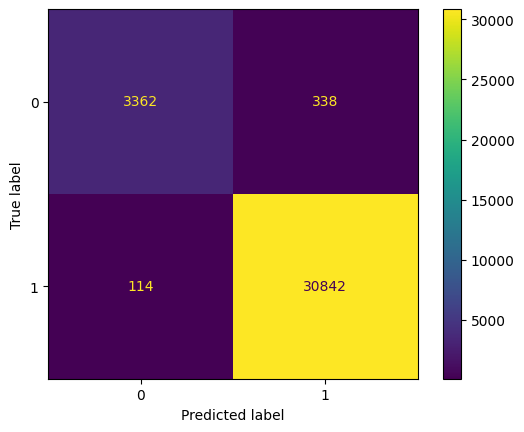

In [134]:
#display confusion matrix of perceptron model
ConfusionMatrixDisplay.from_estimator(perceptron, X_test, y_test)

In [135]:
#logistic regression classifier model fitting
lr = LogisticRegression()
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [136]:
# Predict the labels for the test dataset
pred = lr.predict(X_test)

In [137]:
acc_lr = accuracy_score(y_test, pred)
f1score_lr = f1_score(y_test, pred)
precision_lr = precision_score(y_test, pred)
recall_lr = recall_score(y_test, pred)

print('Logistic Regression Model')
print('-'*25)
print('Accuracy: {:.3f}'.format(acc_lr))
print('Precision: {:.3f}'.format(precision_lr))
print('Recall: {:.3f}'.format(recall_lr))
print('F1-score: {:.3f}'.format(f1score_lr))

Logistic Regression Model
-------------------------
Accuracy: 0.993
Precision: 0.993
Recall: 0.999
F1-score: 0.996


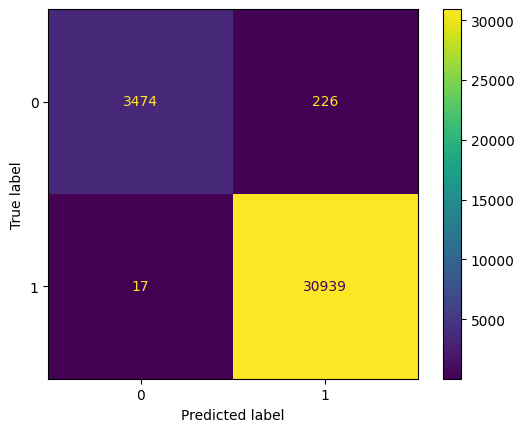

In [138]:
ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test)

In [139]:
#using Adaboost classifier with perceptron estimator 
adaboost_perc = AdaBoostClassifier(estimator=Perceptron(eta0=0.001, random_state=1), n_estimators=100, 
                              learning_rate=0.001, random_state=1).fit(X_train, y_train)

In [140]:
pred = adaboost_perc.predict(X_test)

In [141]:
acc_adaboost_perc2 = accuracy_score(y_test, pred)
f1score_adaboost_perc2 = f1_score(y_test, pred)
precision_adaboost_perc2 = precision_score(y_test, pred)
recall_adaboost_perc2 = recall_score(y_test, pred)

print('AdaBoost Model')
print('-'*20)
print('Accuracy: {:.3f}'.format(acc_adaboost_perc2))
print('Precision: {:.3f}'.format(precision_adaboost_perc2))
print('Recall: {:.3f}'.format(recall_adaboost_perc2))
print('F1-score: {:.3f}'.format(f1score_adaboost_perc2))

AdaBoost Model
--------------------
Accuracy: 0.993
Precision: 0.993
Recall: 0.999
F1-score: 0.996


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


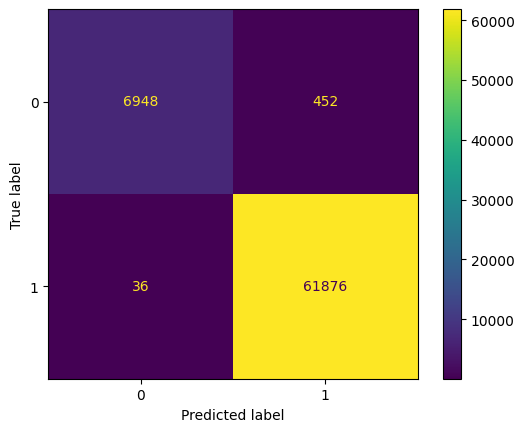

In [142]:
#displays confusion matrix for Adaboost, uses in and out of sample data
ConfusionMatrixDisplay.from_estimator(adaboost_perc, np.concatenate((X_train, X_test), axis=0), 
                                      np.concatenate((y_train, y_test)))

In [143]:
#using the XGboost classifier
xgboost_classifier = XGBClassifier(n_estimators=10)

In [144]:
xgboost_classifier.fit(X_train, y_train, verbose=False)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [145]:
# display the accuracy of the model on the test dataset
xgboost_classifier.score(X_test, y_test)

0.9990189289012004

In [146]:
# predict the class labels for the test dataset
pred = xgboost_classifier.predict(X_test)

In [147]:
acc_xgboost1 = accuracy_score(y_test, pred)
f1score_xgboost1 = f1_score(y_test, pred)
precision_xgboost1 = precision_score(y_test, pred)
recall_xgboost1 = recall_score(y_test, pred)

print('-'*25)
print('XGBoost Model: 4 features')
print('-'*25)
print('Accuracy: {:.3f}'.format(acc_xgboost1))
print('Precision: {:.3f}'.format(precision_xgboost1))
print('Recall: {:.3f}'.format(recall_xgboost1))
print('F1-score: {:.3f}'.format(f1score_xgboost1))

-------------------------
XGBoost Model: 4 features
-------------------------
Accuracy: 0.999
Precision: 0.999
Recall: 1.000
F1-score: 0.999


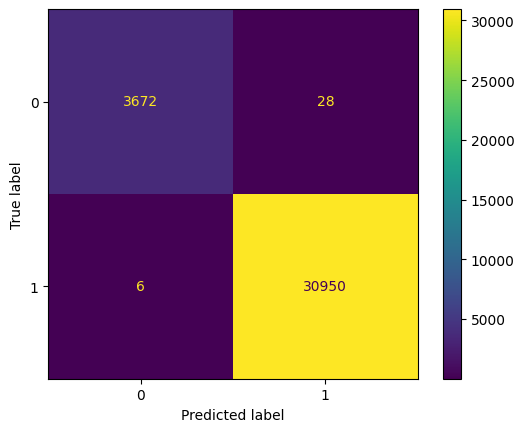

In [148]:
# display confusion matrix for XGboost classifier
ConfusionMatrixDisplay.from_estimator(xgboost_classifier, X_test, y_test)

In [149]:
#create a lightGBM classifier
lgbm_classifier = lgbm.LGBMClassifier(n_estimators=10, max_depth=5, num_leaves=20, verbosity=-1)

In [150]:
lgbm_classifier.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,20
,max_depth,5
,learning_rate,0.1
,n_estimators,10
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [151]:
#accuracy score with classifier
lgbm_classifier.score(X_test, y_test)

0.9964796860572483

In [152]:
pred = lgbm_classifier.predict(X_test)

In [153]:
acc_lgbm = accuracy_score(y_test, pred)
f1score_lgbm = f1_score(y_test, pred)
precision_lgbm = precision_score(y_test, pred)
recall_lgbm = recall_score(y_test, pred)

print('-'*26)
print('LightGBM Model: 4 features')
print('-'*26)
print('Accuracy: {:.3f}'.format(acc_lgbm))
print('Precision: {:.3f}'.format(precision_lgbm))
print('Recall: {:.3f}'.format(recall_lgbm))
print('F1-score: {:.3f}'.format(f1score_lgbm))

--------------------------
LightGBM Model: 4 features
--------------------------
Accuracy: 0.996
Precision: 0.996
Recall: 1.000
F1-score: 0.998


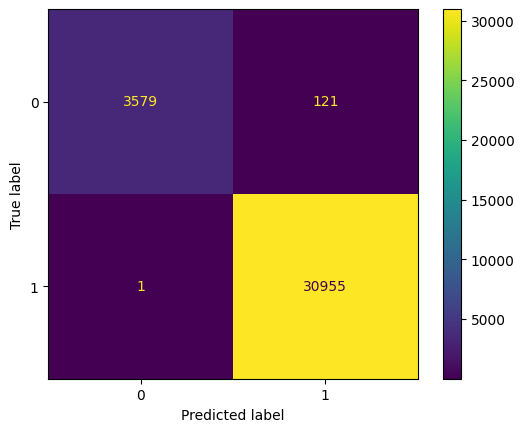

In [154]:
ConfusionMatrixDisplay.from_estimator(lgbm_classifier, X_test, y_test)

In [166]:
print('Perceptron Model')
print('-'*20)
print('Accuracy: {:.3f}'.format(acc_perc))
print('Precision: {:.3f}'.format(precision_perc))
print('Recall: {:.3f}'.format(recall_perc))
print('F1-score: {:.3f}'.format(f1score_perc))
print()
print('Logistic Regression Model')
print('-'*25)
print('Accuracy: {:.3f}'.format(acc_lr))
print('Precision: {:.3f}'.format(precision_lr))
print('Recall: {:.3f}'.format(recall_lr))
print('F1-score: {:.3f}'.format(f1score_lr))
print()


print('AdaBoost Model')
print('-'*20)
print('Accuracy: {:.3f}'.format(acc_adaboost_perc2))
print('Precision: {:.3f}'.format(precision_adaboost_perc2))
print('Recall: {:.3f}'.format(recall_adaboost_perc2))
print('F1-score: {:.3f}'.format(f1score_adaboost_perc2))
print()


print('XGBoost Model: 4 features')
print('-'*20)
print('Accuracy: {:.3f}'.format(acc_xgboost1))
print('Precision: {:.3f}'.format(precision_xgboost1))
print('Recall: {:.3f}'.format(recall_xgboost1))
print('F1-score: {:.3f}'.format(f1score_xgboost1))
print()


print('LightGBM Model: 4 features')
print('-'*20)
print('Accuracy: {:.3f}'.format(acc_lgbm))
print('Precision: {:.3f}'.format(precision_lgbm))
print('Recall: {:.3f}'.format(recall_lgbm))
print('F1-score: {:.3f}'.format(f1score_lgbm))
#

Perceptron Model
--------------------
Accuracy: 0.987
Precision: 0.989
Recall: 0.996
F1-score: 0.993

Logistic Regression Model
-------------------------
Accuracy: 0.993
Precision: 0.993
Recall: 0.999
F1-score: 0.996

AdaBoost Model
--------------------
Accuracy: 0.993
Precision: 0.993
Recall: 0.999
F1-score: 0.996

XGBoost Model: 4 features
--------------------
Accuracy: 0.999
Precision: 0.999
Recall: 1.000
F1-score: 0.999

LightGBM Model: 4 features
--------------------
Accuracy: 0.996
Precision: 0.996
Recall: 1.000
F1-score: 0.998


In [155]:
#conclusion
#XGboost and LGBM 